# Fitting a random diffusion field on the correlations plot

Notebook servant a estimer le champ culturel

## Load data

In [30]:
import polars as pl
from matplotlib import colors
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats
import re
import matplotlib.cm as cm

In [31]:
var = 'pvoteD'

In [32]:
source = f's3://arthurmanceau/election_modeling_uhcp/data/derived/spatial_correlations/c_tau_{var}_r.parquet'
lf = pl.scan_parquet(
    source,
    storage_options={
        "aws_endpoint_url": "https://minio.lab.sspcloud.fr",
        "aws_region": "us-east-1",
    },
    credential_provider=pl.CredentialProviderAWS(
        profile_name="default",
        region_name="us-east-1",
    ),
).collect()


In [33]:
def plot_election_correlations(
    lf: pl.DataFrame,
    mode: str = "both",                 # "pres" | "leg" | "both"
    year_window: tuple[int, int] | None = None,  # (start_year, end_year), inclusive
    include_t2: bool = True,
    figsize: tuple[int, int] = (20, 10),
):
    def strip_t2(label: str):
        s = label.strip()
        if s.startswith("T2_"):
            return s[3:], True
        if s.startswith("T2"):
            return s[2:], True
        return s, False

    def parse_label(label: str):
        base, is_t2 = strip_t2(label.lower())
        m = re.fullmatch(r"(pres|leg)_?(\d{4})", base)
        if not m:
            return None
        return {
            "raw": label,
            "base": base,
            "type": m.group(1),
            "year": int(m.group(2)),
            "is_t2": is_t2,
        }

    if mode not in {"pres", "leg", "both"}:
        raise ValueError("mode must be one of: 'pres', 'leg', 'both'")

    labels = lf.select("election_code").unique().get_column("election_code").to_list()
    parsed = [parse_label(lbl) for lbl in labels]
    parsed = [p for p in parsed if p is not None]

    # Filter by mode
    if mode != "both":
        parsed = [p for p in parsed if p["type"] == mode]

    # Filter T2
    if not include_t2:
        parsed = [p for p in parsed if not p["is_t2"]]

    # Filter by year window
    if year_window is not None:
        y0, y1 = year_window
        parsed = [p for p in parsed if y0 <= p["year"] <= y1]

    if not parsed:
        raise ValueError("No labels matched the requested filters.")

    parsed = sorted(parsed, key=lambda p: p["year"])

    # Build dataframes
    dataframes = {}
    for p in parsed:
        dataframes[p["raw"]] = (
            lf.filter(pl.col("election_code") == p["raw"])
            .select(
                pl.col("mid").alias("distance_bin"),
                pl.col("C_tau").alias("correlation"),
            )
            .sort("distance_bin")
        )

    colormap_by_type = {"pres": cm.PuRd, "leg": cm.Blues}
    selected_types = sorted(set(p["type"] for p in parsed))

    # Norm per type
    norm_by_type = {}
    for t in selected_types:
        ys = [p["year"] for p in parsed if p["type"] == t]
        vmin, vmax = min(ys), max(ys)
        if vmin == vmax:
            vmax = vmin + 1
        norm_by_type[t] = colors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)

    for p in parsed:
        df = dataframes[p["raw"]]
        t = p["type"]
        year = p["year"]
        color = colormap_by_type[t](norm_by_type[t](year))

        ax.plot(
            df.get_column("distance_bin").to_numpy() * 1.5,
            df.get_column("correlation").to_numpy(),
            label=p["base"],
            linestyle=":" if p["is_t2"] else "-",
            marker="o" if p["is_t2"] else "+",
            linewidth=0.7,
            markersize=1.5,
            color=color,
        )

    ax.axvline(x=10, color="red", linestyle="--", label="l_c = 10 km")
    ax.axvline(x=300, color="red", linestyle="--", label="L_c = 300 km")
    ax.set_xscale("log")
    ax.set_xlabel("Distance Bin")
    ax.set_ylabel("Correlation $C_{\\tau}(r)$")
    ax.set_title(f"Correlation Across Elections ({mode})")
    ax.grid(True)
    ax.legend(ncol=2, fontsize=8)

    # Colorbars by selected type
    for t in selected_types:
        sm = cm.ScalarMappable(cmap=colormap_by_type[t], norm=norm_by_type[t])
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.02)
        cbar.set_label("Presidential Elections" if t == "pres" else "Legislative Elections")

    plt.show()
    return fig, ax

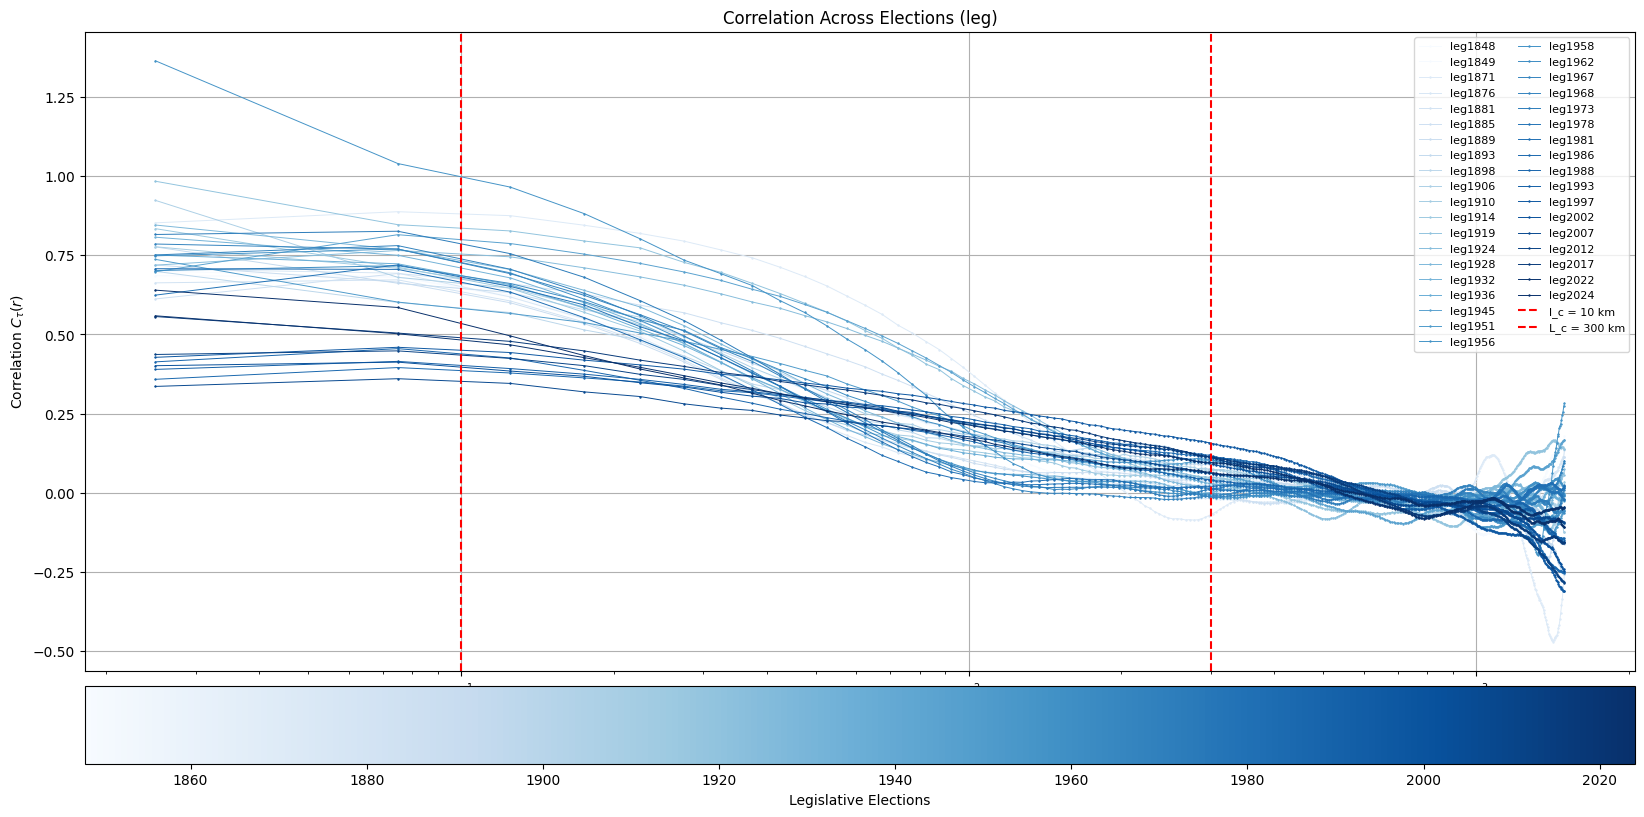

(<Figure size 2000x1000 with 2 Axes>,
 <Axes: title={'center': 'Correlation Across Elections (leg)'}, xlabel='Distance Bin', ylabel='Correlation $C_{\\tau}(r)$'>)

In [40]:
plot_election_correlations(lf, mode="leg")

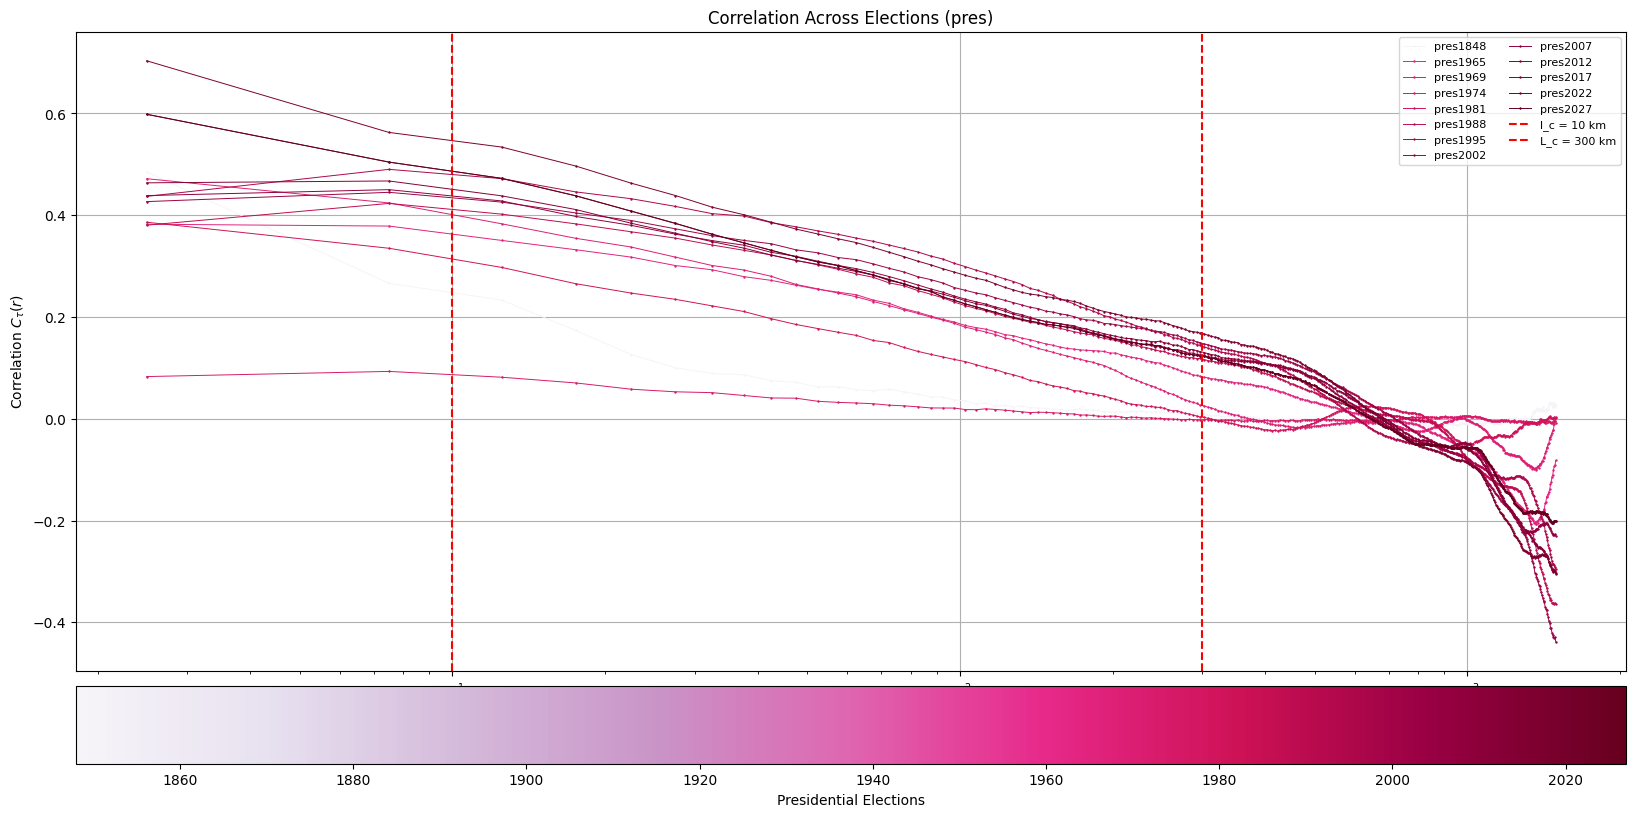

(<Figure size 2000x1000 with 2 Axes>,
 <Axes: title={'center': 'Correlation Across Elections (pres)'}, xlabel='Distance Bin', ylabel='Correlation $C_{\\tau}(r)$'>)

In [35]:
plot_election_correlations(lf, mode="pres")

Mean correlations plot

## Fitting

Soit $\phi(t, R)$ un champ bidemnsionnelle qui est régit par l'équation : 
$$
\dfrac{\partial \phi(t, R)}{\partial t} = d \Delta \phi(t, R) + \eta(t, R)
$$

Avec $C_{\phi}(r) = -\lambda^2  \log \left( \dfrac{r}{L} \right)$ for $l_c \leq r \leq L$

In [36]:
l_c = 4.5
L_c = 300

In [37]:
def get_lambda_L(slope, intercept):
    lambd = np.sqrt(-slope)
    L = np.exp(intercept / lambd**2)
    return lambd, L

In [38]:
def fit_election(df, L_c, l_c, confidence_level=0.95, plot=True, resid=True):
    """
    This function will fit for a given election

    """
    C = df["correlation"]
    r = df["distance_bin"] * 1.5

    # Cut before l_c
    indices_ = np.where(r > l_c)[0]
    indices_2 = np.where(r < L_c)[0]
    indices = np.intersect1d(indices_, indices_2)
    C_ = C[indices].values
    r_ = r[indices].values
    r_log = np.log(r_)

    # Linear regression C = A*ln(r) = -lambda**2 * ln(r/L)
    r_reshaped = r_log.reshape(-1, 1)

    model = LinearRegression()
    model.fit(r_reshaped, C_)

    slope = model.coef_[0]
    intercept = model.intercept_
    print(f"Fitted line: C = {slope:.3f} * ln(r) + {intercept:.3f}")

    R_2 = model.score(r_reshaped, C_)
    print("Quality of the regression : " + str(R_2))

    residuals = C_ - model.predict(r_reshaped)
    n = len(C_)
    p = 1

    mse = np.sum(residuals**2) / (n - p - 1)
    se_slope = np.sqrt(mse / np.sum((r_reshaped - np.mean(r_reshaped)) ** 2))
    se_intercept = np.sqrt(
        mse
        * (
            1 / n
            + np.mean(r_reshaped) ** 2 / np.sum((r_reshaped - np.mean(r_reshaped)) ** 2)
        )
    )  # Standard error of the intercept

    t_value = stats.t.ppf(1 - (1 - confidence_level) / 2, df=n - p - 1)

    slope_ci = (slope - t_value * se_slope, slope + t_value * se_slope)
    intercept_ci = (
        intercept - t_value * se_intercept,
        intercept + t_value * se_intercept,
    )

    lambd, L = get_lambda_L(slope, intercept)

    # Propagate uncertainty for lambd
    se_lambd = (1 / (2 * np.sqrt(-slope))) * se_slope
    lambd_ci = (lambd - t_value * se_lambd, lambd + t_value * se_lambd)

    # Propagate uncertainty for L
    se_L = (L / slope) * se_intercept + (L * intercept / slope**2) * se_slope
    L_ci = (L - t_value * se_L, L + t_value * se_L)

    lambd, L = get_lambda_L(slope, intercept)
    print(f"C = -({lambd**2:.3f}+/-{se_lambd:.3f}) * ln(r/({L:.3f}+/-{se_L:.3f}))")

    if plot:
        # Plot curve and fit
        plt.figure(figsize=(8, 6))
        plt.scatter(r_, C_, color="blue", label="Data", s=1)
        plt.plot(r_, model.predict(r_reshaped), color="red", label="Fitted Line")
        plt.xlabel("r (km)")
        plt.xscale("log")
        plt.ylabel("C (correlation)")
        plt.legend()
        plt.show()

    if resid:
        # Plot residuals
        plt.figure(figsize=(8, 6))
        plt.scatter(r_, residuals, color="green", s=4)
        plt.axhline(0, color="black", linestyle="--")
        plt.xlabel("r")
        plt.ylabel("Residuals")
        plt.title("Residuals of the Fit")
        plt.show()

    return lambd, L, R_2

In [39]:
LAMBD = {}
L_d = {}
R = {}
for key, df in dataframes.items():
    print(key)
    lambd, L, R_2 = fit_election(df, L_c, l_c, plot=True, resid=True)
    LAMBD[key] = lambd
    L_d[key] = L
    R[key] = R_2

pres1995


AttributeError: 'Series' object has no attribute 'values'

In [ ]:
LAMBD

{'leg_1988': 0.31538872768026516,
 'ref_1795': 0.41385116458036786,
 'ref_1793': 0.43566502159675036,
 'T2_pres_2022': 0.2382970279810511,
 'leg_1973': 0.4704366392351438,
 'leg_1928': 0.28527658056364813,
 'pres_1969': 0.318697238195543,
 'T2_pres_1969': 0.31580464047313767,
 'pres_1981': 0.3180614951606103,
 'pres_1995': 0.27575758360752234,
 'T2_pres_1981': 0.2658688615662113,
 'leg_2012': 0.22454791193220935,
 'leg_1902': 0.3090460872262543,
 'leg_1898': 0.2992951143242553,
 'leg_1910': 0.3208777878008231,
 'pres_1974': 0.28045527285564176,
 'T2_pres_1974': 0.25772626931962384,
 'pres_1988': 0.3344472581685725,
 'T2_pres_1988': 0.27027402719702603,
 'leg_2022': 0.23010325021389738,
 'pres_1965': 0.3314448663254118,
 'leg_1919': 0.3356433845999175,
 'pres_2012': 0.21720380055252625,
 'T2_pres_2012': 0.20722930618858829,
 'pres_2007': 0.23226710242446286,
 'ref_1946': 0.3168932957941572,
 'pres_2022': 0.2417465208086845,
 'ref_1992': 0.2871210553892,
 'pres_1848': 0.38675017341327556

In [ ]:
# Combine dictionaries into a DataFrame
data = {
    "Key": list(R.keys()),
    "R": list(R.values()),
    "L_d": list(L_d.values()),
    "LAMBD^2": list(([lambd**2 for key, lambd in LAMBD.items()])),
}

df = pd.DataFrame(data)

# Sort the DataFrame by the 'Key' column (ascending order)
df_sorted = df.sort_values(by="Key").reset_index(drop=True)

# Display the table
print(df_sorted)

lambda_mean = np.mean(list(LAMBD.values()))
print("lambda_mean **2 : " + str(lambda_mean**2))

L_mean = np.mean(list(L_d.values()))
print("L_mean : " + str(L_mean))

R_2_mean = np.mean(list(R.values()))
print("R_2_mean : " + str(R_2_mean))

             Key         R          L_d   LAMBD^2
0   T2_pres_1969  0.987501   249.244370  0.099733
1   T2_pres_1974  0.976054   286.902813  0.066423
2   T2_pres_1981  0.982885   313.902931  0.070686
3   T2_pres_1988  0.976277   240.605674  0.073048
4   T2_pres_2012  0.974522   292.729120  0.042944
5   T2_pres_2017  0.923438   183.974996  0.051700
6   T2_pres_2022  0.888957   193.679622  0.056785
7       leg_1871  0.872705   188.077662  0.114628
8       leg_1898  0.901726   260.607618  0.089578
9       leg_1902  0.914945   228.923894  0.095509
10      leg_1910  0.929839   322.491846  0.102963
11      leg_1919  0.844147   187.242913  0.112656
12      leg_1928  0.992630   466.347329  0.081383
13      leg_1973  0.951610   465.164022  0.221311
14      leg_1986  0.972941   246.811012  0.094934
15      leg_1988  0.990118   254.746740  0.099470
16      leg_1993  0.993363   265.996277  0.085446
17      leg_2012  0.988931   262.567658  0.050422
18      leg_2022  0.981817  1055.799039  0.052948


Valeur dans l'article : The average logarithmic slope $\lambda^2$ is found to be  0.065±0.01 for turnout rates, and 0.11±0.02 for winning votes

On s'interesse à $\beta \sigma_{\phi}^2 = lim_{r\to0^+} C(r)$

In [ ]:
SIGMA_PHI = {}
for key in dataframes.keys():
    SIGMA_PHI[key] = dataframes[key].iloc[0]["correlation"]

In [ ]:
SIGMA_PHI

{'leg_1988': 0.364700271914542,
 'ref_1795': 0.8456387482424282,
 'ref_1793': 0.9224729544600799,
 'T2_pres_2022': 0.26672954015375205,
 'leg_1973': 0.8860280138719547,
 'leg_1928': 0.46676663327134965,
 'pres_1969': 0.4236080434653361,
 'T2_pres_1969': 0.45638078695748013,
 'pres_1981': 0.4098793197730662,
 'pres_1995': 0.2831032493999041,
 'T2_pres_1981': 0.2946380760957774,
 'leg_2012': 0.1494758873335705,
 'leg_1902': 0.5118685378588705,
 'leg_1898': 0.40858325061205547,
 'leg_1910': 0.5239479255133146,
 'pres_1974': 0.28475597774724615,
 'T2_pres_1974': 0.3378208006917974,
 'pres_1988': 0.45733527466736973,
 'T2_pres_1988': 0.2942295659700394,
 'leg_2022': 0.07853051229469357,
 'pres_1965': 0.41705301861082716,
 'leg_1919': 0.4444269647496801,
 'pres_2012': 0.1480678371018657,
 'T2_pres_2012': 0.1542543384822392,
 'pres_2007': 0.146415665194202,
 'ref_1946': 0.4567170823659816,
 'pres_2022': 0.21413831583789494,
 'ref_1992': 0.2820165066300463,
 'pres_1848': 0.8411670240504856,
 '